# 1. Import Libraries

In [1]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Data Splitting
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Machine Learning Model
from sklearn.tree import DecisionTreeClassifier

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Handling Imbalanced Data
import imblearn
from imblearn.over_sampling import SMOTE

# Model Persistence
import joblib

Tahap ini memuat seluruh dependensi untuk analisis dan pemodelan. `pandas` dan `numpy` digunakan untuk manipulasi data, sedangkan `matplotlib` untuk visualisasi. Modul `sklearn` menangani pembagian data, evaluasi model, serta algoritma klasifikasi Decision Tree. `StandardScaler` digunakan untuk normalisasi fitur, dan `SMOTE` untuk mengatasi ketidakseimbangan kelas. Terakhir, `joblib` digunakan untuk menyimpan model dan scaler agar dapat digunakan kembali pada tahap deployment.

# 2. Load Dataset

In [5]:
df = pd.read_csv('../data/diabetes.csv')

# 3. Exploratory Data Analysis (EDA)

In [6]:
# Menampilkan 5 baris pertama dari dataset untuk melihat gambaran awal
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# Jumlah baris dan Kolom
df.shape

(768, 9)

In [8]:
# Jumlah data tiap atribut
df.count()

Pregnancies                 768
Glucose                     768
BloodPressure               768
SkinThickness               768
Insulin                     768
BMI                         768
DiabetesPedigreeFunction    768
Age                         768
Outcome                     768
dtype: int64

In [9]:
# Menampilkan informasi ringkas tentang dataset (tipe data, non-null counts)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
# Menampilkan statistik deskriptif (mean, std, min, max, dll.)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Statistik deskriptif memberikan gambaran umum distribusi tiap fitur, termasuk nilai rata-rata, standar deviasi, serta rentang nilai. Terlihat beberapa fitur memiliki nilai minimum 0 pada atribut yang secara medis tidak valid, seperti *Glucose*, *BloodPressure*, *SkinThickness*, *Insulin*, dan *BMI*. Hal ini mengindikasikan adanya *missing value terselubung*. Selain itu, fitur seperti *Insulin* memiliki variansi tinggi yang menunjukkan kemungkinan adanya outlier, sehingga perlu penanganan pada tahap preprocessing.

In [11]:
# Memeriksa apakah masih ada nilai null setelah imputasi
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
# Memeriksa jumlah data duplikat
print(df.duplicated().sum())

0


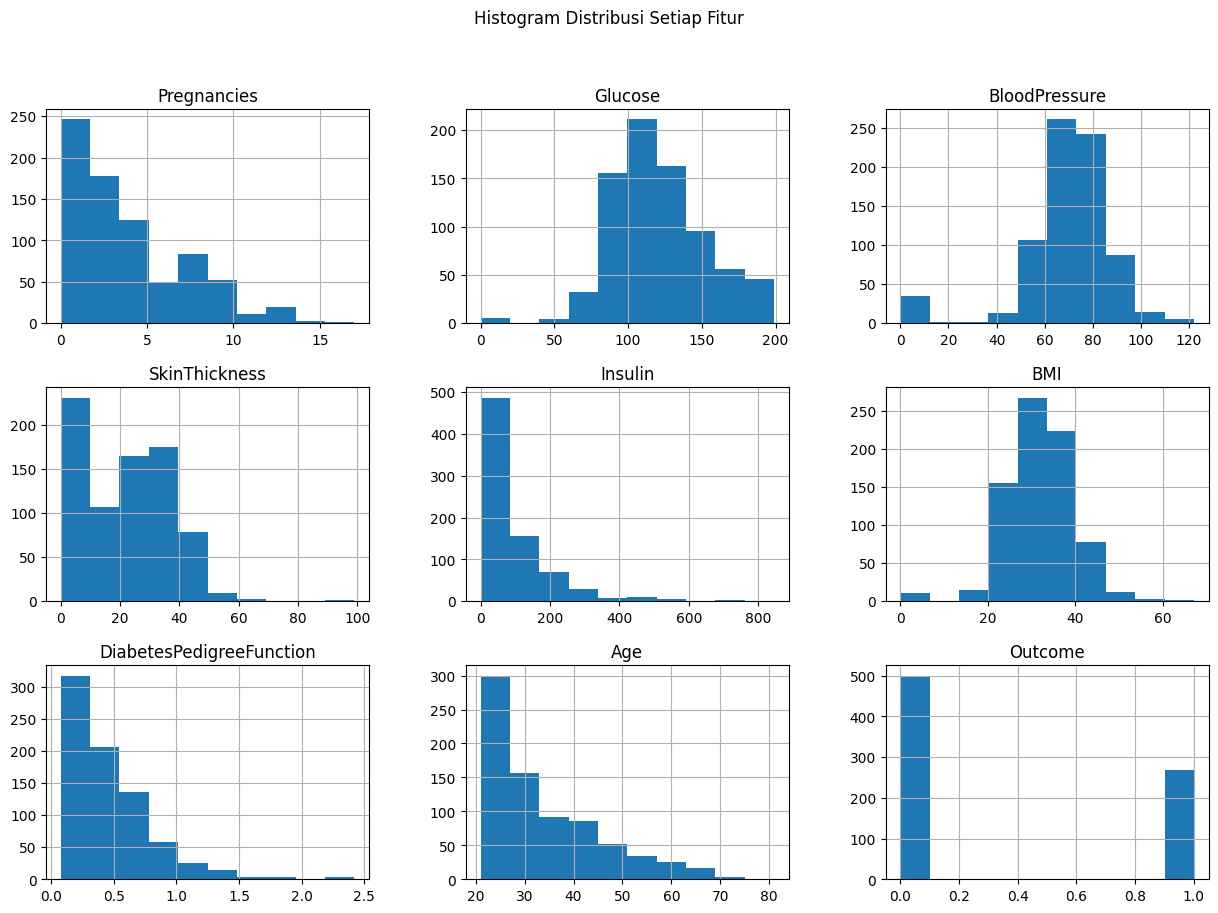

In [13]:
# Histogram untuk setiap fitur
# Ini membantu untuk melihat distribusi dari setiap variabel.
df.hist(figsize=(15, 10))
plt.suptitle('Histogram Distribusi Setiap Fitur')
plt.show()

Histogram digunakan untuk memahami distribusi setiap fitur dalam dataset. Terlihat bahwa beberapa fitur seperti *Glucose*, *BloodPressure*, dan *BMI* mendekati distribusi normal, sedangkan *Insulin*, *SkinThickness*, dan *DiabetesPedigreeFunction* cenderung skewed (miring) dan memiliki outlier. Selain itu, terdapat indikasi nilai nol yang tidak wajar pada beberapa fitur. Informasi ini penting untuk menentukan strategi preprocessing seperti imputasi dan transformasi data.

In [14]:
print((df == 0).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Beberapa atribut seperti *Glucose*, *BloodPressure*, *SkinThickness*, *Insulin*, dan *BMI* tidak seharusnya bernilai nol secara medis, sehingga dianggap sebagai *missing values terselubung*. Hasil menunjukkan jumlah nol yang cukup signifikan, terutama pada *Insulin* dan *SkinThickness*. Oleh karena itu, diperlukan proses imputasi agar tidak menurunkan kualitas dan performa model.

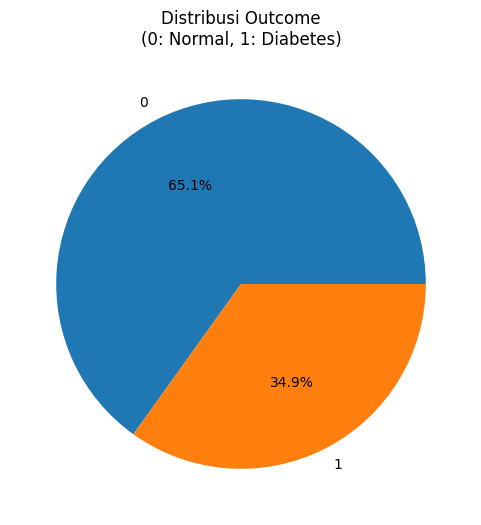

In [15]:
# Distribusi Label menggunakan pie plot
df['Outcome'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6, 6),
    title='Distribusi Outcome\n(0: Normal, 1: Diabetes)'
)
plt.show()

Visualisasi pie chart menunjukkan distribusi kelas target, yaitu 65.1% non-diabetes (0) dan 34.9% diabetes (1). Hal ini mengindikasikan adanya ketidakseimbangan kelas (*imbalanced dataset*), di mana kelas mayoritas mendominasi. Kondisi ini dapat menyebabkan model cenderung bias terhadap kelas mayoritas. Oleh karena itu, diperlukan teknik penanganan imbalance seperti SMOTE agar model dapat belajar secara lebih seimbang.

# 4. Train-Test Split

In [17]:
# Pisahkan Fitur (X) dan Label (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data menjadi data latih (train) dan data uji (test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menamplikan distribusi split
print("Jumlah X_train:", len(X_train))
print("Jumlah X_test :", len(X_test))
print("Jumlah y_train:", len(y_train))
print("Jumlah y_test :", len(y_test))

Jumlah X_train: 614
Jumlah X_test : 154
Jumlah y_train: 614
Jumlah y_test : 154


Data dipisahkan menjadi fitur (X) dan label (y), kemudian dibagi menjadi data latih (80%) dan data uji (20%). Penggunaan parameter *stratify=y* memastikan distribusi kelas tetap seimbang antara data train dan test. Hal ini penting untuk menjaga representasi data dan menghasilkan evaluasi model yang lebih valid. Hasil pembagian menunjukkan 614 data untuk pelatihan dan 154 data untuk pengujian.

# 5. Handle Missing Values

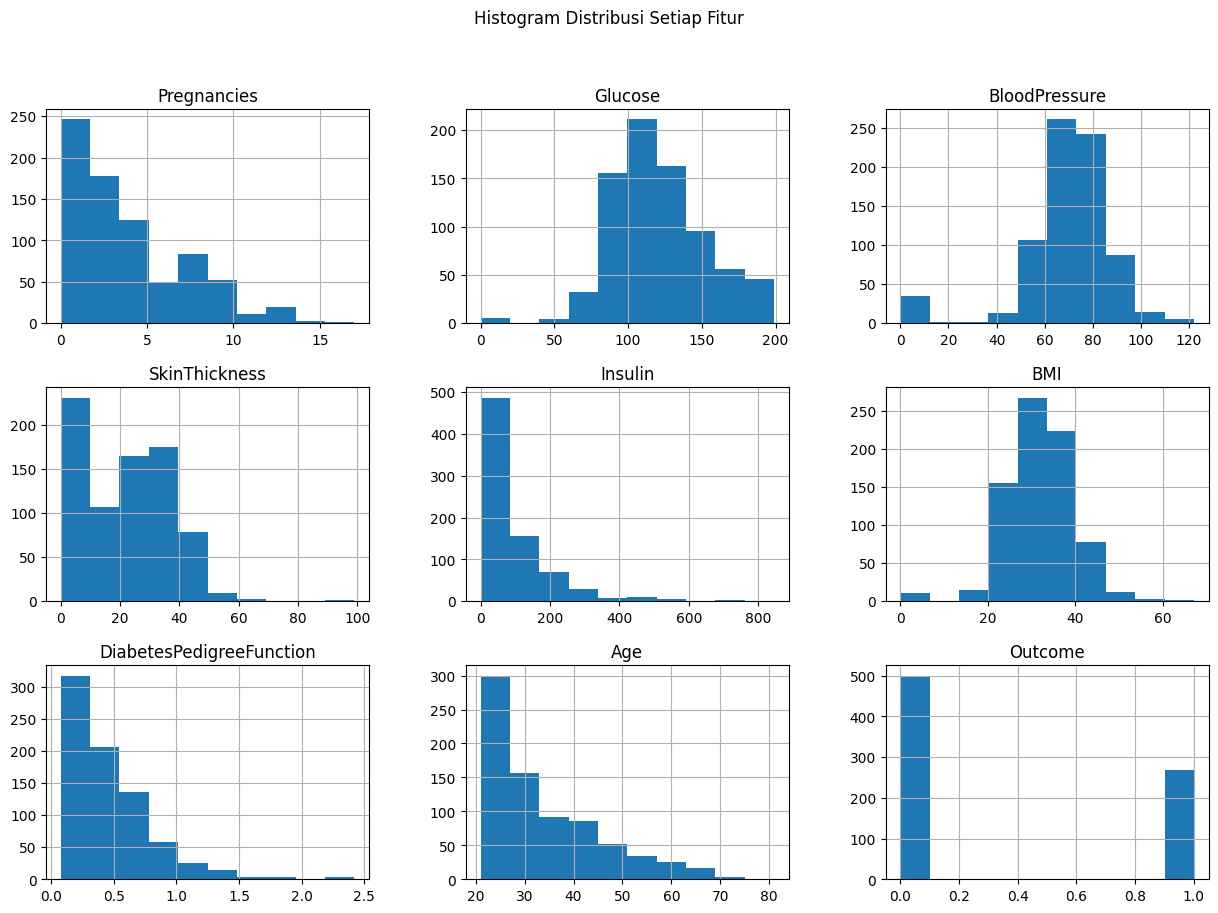

In [18]:
# Mengganti nilai 0 dengan median
cols = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'SkinThickness']

for col in cols:
    median_val = X_train.loc[X_train[col] != 0, col].median()

    X_train.loc[X_train[col] == 0, col] = median_val
    X_test.loc[X_test[col] == 0, col] = median_val

# Visualisasi distribusi setiap fitur
df.hist(figsize=(15, 10))
plt.suptitle('Histogram Distribusi Setiap Fitur')
plt.show()

Nilai nol pada beberapa fitur digantikan menggunakan median dari data latih untuk menghindari bias dan *data leakage*. Median dipilih karena lebih robust terhadap outlier dibanding mean. Setelah imputasi, distribusi data menjadi lebih realistis tanpa spike di nilai nol.

Dalam konteks medis, imputasi statistik seperti median hanyalah pendekatan praktis. Idealnya, imputasi dilakukan berbasis domain knowledge (misalnya rentang normal klinis atau konsultasi ahli), karena nilai fisiologis memiliki batas biologis tertentu. Pendekatan domain-driven lebih akurat, namun tidak selalu tersedia.

# 6. Feature Scaling (StandardScaler)

In [22]:
# StandardScaler digunakan untuk menstandarisasi fitur
scaler = StandardScaler()

# Fit hanya pada training (hindari data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test menggunakan parameter dari training
X_test_scaled = scaler.transform(X_test)

# Konversi ke df agar mudah terbaca
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [23]:
print("Sebelum Scaling (Train):")
X_train.head()

Sebelum Scaling (Train):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,12,43,27.2,0.580,24
711,5,126,78,27,22,29.6,0.439,40
373,2,105,58,40,94,34.9,0.225,25
46,1,146,56,29,125,29.7,0.564,29
682,0,95,64,39,105,44.6,0.366,22


In [24]:
print("\nSetelah Scaling (Train):")
X_train_scaled_df.head()


Setelah Scaling (Train):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417714,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.403048,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782163,-0.337630,-0.961320


StandardScaler digunakan untuk menstandarisasi fitur sehingga memiliki distribusi dengan mean ≈ 0 dan standar deviasi ≈ 1. Proses *fit* dilakukan hanya pada data training untuk menghindari *data leakage*, kemudian parameter tersebut diterapkan pada data testing.

Setelah scaling, seluruh fitur berada pada skala yang seragam, sehingga model yang sensitif terhadap skala dapat bekerja lebih optimal. Meskipun Decision Tree tidak memerlukan scaling, langkah ini penting untuk menjaga konsistensi pipeline jika menggunakan model lain.

# 7. Handle Imbalanced Data (SMOTE)

In [25]:
# Balancing dengan Synthetic Minority Over-sampling Technique (SMOTE)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Distribusi SEBELUM SMOTE:")
print(y_train.value_counts())

print("\nDistribusi setelah SMOTE:")
print(y_train_res.value_counts())

Distribusi SEBELUM SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

Distribusi setelah SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


SMOTE digunakan untuk mengatasi ketidakseimbangan kelas dengan menghasilkan data sintetis pada kelas minoritas. Sebelum SMOTE, distribusi data menunjukkan ketimpangan (400:214), kemudian menjadi seimbang (400:400) setelah proses oversampling. Hal ini membantu model belajar lebih adil terhadap kedua kelas.

Namun, dalam konteks medis, penggunaan data sintetis perlu hati-hati karena dapat menghasilkan pola yang tidak sepenuhnya merepresentasikan kondisi klinis nyata. Oleh karena itu, SMOTE pada kasus ini digunakan sebagai pendekatan pembelajaran, bukan praktik klinis final.

# 8. Model Training (Decision Tree)

In [26]:
# Inisialisasi model Decision Tree dengan pembatasan kedalaman untuk mencegah overfitting
model = DecisionTreeClassifier(
    max_depth=4,        # batas maksimum kedalaman pohon
    random_state=42     # memastikan hasil reproducible
)

# Melatih model menggunakan data training yang sudah di-balance dengan SMOTE
model.fit(X_train_res, y_train_res)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Model Decision Tree digunakan untuk melakukan klasifikasi dengan membangun struktur pohon keputusan berdasarkan fitur input. Parameter *max_depth=4* diterapkan untuk membatasi kompleksitas model dan mengurangi risiko overfitting. Model dilatih menggunakan data hasil oversampling (SMOTE) agar dapat mempelajari pola secara seimbang antara kelas mayoritas dan minoritas. Pendekatan ini menghasilkan model yang lebih general dan tidak bias terhadap salah satu kelas.

# 9. Model Evaluation

In [27]:
# Train Evaluation
y_train_pred = model.predict(X_train_res)
y_train_prob = model.predict_proba(X_train_res)[:, 1]

print("\nTrain Evaluation:")
print("Accuracy:", accuracy_score(y_train_res, y_train_pred))
print(classification_report(y_train_res, y_train_pred))
print(confusion_matrix(y_train_res, y_train_pred))
print("ROC AUC:", roc_auc_score(y_train_res, y_train_prob))


Train Evaluation:
Accuracy: 0.81375
              precision    recall  f1-score   support

           0       0.89      0.72      0.79       400
           1       0.76      0.91      0.83       400

    accuracy                           0.81       800
   macro avg       0.83      0.81      0.81       800
weighted avg       0.83      0.81      0.81       800

[[288 112]
 [ 37 363]]
ROC AUC: 0.884953125


Evaluasi pada data training menunjukkan akurasi sebesar 81.37% dengan ROC AUC 0.88, yang mengindikasikan kemampuan klasifikasi yang baik. Model memiliki recall tinggi pada kelas diabetes (0.91), artinya mampu mendeteksi sebagian besar kasus positif. Namun, precision lebih rendah (0.76), menunjukkan masih terdapat false positive. Secara keseluruhan, performa cukup seimbang, meskipun perlu diuji lebih lanjut pada data testing untuk memastikan generalisasi model.

In [28]:
# Test Evaluation
y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\nTest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))


Test Evaluation:
Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.61      0.85      0.71        54

    accuracy                           0.75       154
   macro avg       0.75      0.78      0.75       154
weighted avg       0.79      0.75      0.76       154

[[70 30]
 [ 8 46]]
ROC AUC: 0.793611111111111


Pada data testing, model memperoleh akurasi sebesar 75.32% dengan ROC AUC 0.79, menunjukkan performa yang cukup baik dalam generalisasi. Recall untuk kelas diabetes (0.85) tetap tinggi, yang penting dalam konteks medis untuk meminimalkan kasus yang terlewat. Namun, precision (0.61) menunjukkan masih adanya false positive. Perbedaan performa antara training dan testing relatif kecil, menandakan model tidak mengalami overfitting signifikan dan cukup stabil.

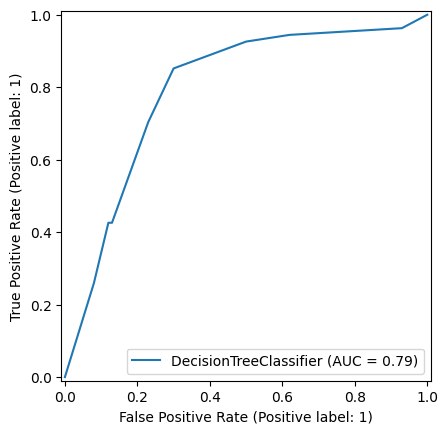

In [29]:
# ROC CURVE
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.show()

ROC Curve menunjukkan hubungan antara True Positive Rate (TPR) dan False Positive Rate (FPR) pada berbagai threshold. Kurva yang mendekati sudut kiri atas menandakan performa model yang baik. Nilai AUC sebesar 0.79 mengindikasikan kemampuan model dalam membedakan kelas diabetes dan non-diabetes tergolong cukup baik.

# 10. Feature Importance Analysis

In [30]:
# Feature Importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
Glucose                     0.560785
BMI                         0.254983
Age                         0.137955
DiabetesPedigreeFunction    0.018310
Insulin                     0.017607
Pregnancies                 0.010360
SkinThickness               0.000000
BloodPressure               0.000000
dtype: float64


Feature importance menunjukkan kontribusi masing-masing fitur dalam proses pengambilan keputusan model. Terlihat bahwa *Glucose* menjadi fitur paling dominan, diikuti oleh *BMI* dan *Age*, yang secara klinis memang relevan dengan risiko diabetes. Sementara itu, beberapa fitur seperti *SkinThickness* dan *BloodPressure* memiliki kontribusi sangat kecil atau nol. Informasi ini penting untuk interpretasi model serta dapat digunakan dalam seleksi fitur pada pengembangan model selanjutnya.

# 11. Model Export (Persistence)

In [31]:
# Save model & scaler
joblib.dump(model, '../models/decision_tree_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')

# Jika mau kembali load
# loaded_model = joblib.load('decision_tree_model.joblib')
# loaded_scaler = joblib.load('scaler.joblib')

# Contoh prediksi
# data_baru = [[...]]  # input user
# data_scaled = loaded_scaler.transform(data_baru)
# prediksi = loaded_model.predict(data_scaled)

['../models/scaler.joblib']